In [13]:
# !pip install transformers==4.44.2
# !pip install datasets
# !pip install accelerate
# !pip install protobuf==3.20.*
!pip install datasets evaluate



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.6 MB/s eta 0:00:00


In [ ]:
# !pip uninstall -y transformers accelerate peft protobuf
# !pip install transformers==4.40.2
# !pip install accelerate==0.30.1
# !pip install peft==0.11.1


In [2]:
from datasets import load_dataset, Dataset, ClassLabel
import pandas as pd
import numpy as np


In [3]:
dataset = load_dataset("srikanthgali/ai-text-detection-pile-cleaned")
df = dataset['train'].to_pandas()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00003.parquet:   0%|          | 0.00/265M [00:00<?, ?B/s]

data/train-00001-of-00003.parquet:   0%|          | 0.00/264M [00:00<?, ?B/s]

data/train-00002-of-00003.parquet:   0%|          | 0.00/265M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/100M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/99.4M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/577300 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/72162 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/72164 [00:00<?, ? examples/s]

In [4]:
df_sampled = (
    df.groupby("generated")
      .apply(lambda x: x.sample(min(20000, len(x)), random_state=42))
      .reset_index(drop=True)
)
df_sampled.head()


/tmp/ipython-input-2474815456.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(20000, len(x)), random_state=42))


,text,generated,source
0,How to Trim your Climbing Rope Sport climbers ...,0,human
1,"There s a princess in that tower, and I m go...",0,human
2,"Zorb. Zorb. dammit, Zorb, you gon na hand me t...",0,human
3,We had been on the hunt for treasure for what ...,0,human
4,The most profoundly honest and deep conversati...,0,human


In [5]:
dataset_small = Dataset.from_pandas(df_sampled)

# Keep only text + labels
dataset_small = dataset_small.remove_columns(
    [col for col in dataset_small.column_names if col not in ["text", "generated"]]
)

# Rename column
dataset_small = dataset_small.rename_column("generated", "labels")

# Convert labels to ClassLabel type
class_label = ClassLabel(names=["human", "ai"])
dataset_small = dataset_small.cast_column("labels", class_label)


Casting the dataset:   0%|          | 0/40000 [00:00<?, ? examples/s]

In [6]:
# Stratified split in pandas (works in all environments)

from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(
    df_sampled,
    test_size=0.2,
    stratify=df_sampled["generated"],
    random_state=42
)

# Convert to HF Datasets
train_ds = Dataset.from_pandas(df_train).remove_columns(["__index_level_0__"])
val_ds   = Dataset.from_pandas(df_test).remove_columns(["__index_level_0__"])

# Make sure labels are ClassLabel
train_ds = train_ds.rename_column("generated", "labels")
val_ds   = val_ds.rename_column("generated", "labels")

class_label = ClassLabel(names=["human", "ai"])
train_ds = train_ds.cast_column("labels", class_label)
val_ds   = val_ds.cast_column("labels", class_label)

train_ds, val_ds


Casting the dataset:   0%|          | 0/32000 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/8000 [00:00<?, ? examples/s]

(Dataset({
     features: ['text', 'labels', 'source'],
     num_rows: 32000
 }),
 Dataset({
     features: ['text', 'labels', 'source'],
     num_rows: 8000
 }))

In [7]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)


The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [8]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

train_ds_tokenized = train_ds.map(tokenize, batched=True)
val_ds_tokenized   = val_ds.map(tokenize, batched=True)

train_ds_tokenized.set_format("torch")
val_ds_tokenized.set_format("torch")


Map:   0%|          | 0/32000 [00:00<?, ? examples/s]

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

# Training

In [9]:
import torch
torch.cuda.is_available(), torch.cuda.get_device_name(0)


(True, 'Tesla T4')

In [30]:
from transformers import TrainingArguments, Trainer
import evaluate

accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(-1)
    return {
        "accuracy": accuracy.compute(predictions=preds, references=labels)["accuracy"],
        "f1": f1.compute(predictions=preds, references=labels, average="weighted")["f1"]
    }

training_args = TrainingArguments(
    output_dir="./distilbert-output",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=3e-5,    # DistilBERT likes a slightly higher LR
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=2,
    num_train_epochs=3,
    fp16=True,
    report_to="none",
    load_best_model_at_end=True
)


/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [31]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds_tokenized,
    eval_dataset=val_ds_tokenized,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)


In [32]:
trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.044000,0.353842,0.940125,0.939957
2,0.021300,0.226189,0.958125,0.958090
3,0.007400,0.362880,0.948000,0.947896


TrainOutput(global_step=3000, training_loss=0.027589651266733805, metrics={'train_runtime': 966.8344, 'train_samples_per_second': 99.293, 'train_steps_per_second': 3.103, 'total_flos': 6358435135488000.0, 'train_loss': 0.027589651266733805, 'epoch': 3.0})

In [33]:
save_dir = "./final_distilbert_model"

trainer.save_model(save_dir)
tokenizer.save_pretrained(save_dir)
model.config.save_pretrained(save_dir)

print("DistilBERT saved to:", save_dir)


DistilBERT saved to: ./final_distilbert_model


# Evaluations

In [36]:
import pandas as pd

# Convert HF to pandas
df = pd.DataFrame(dataset["train"])

# Sample smaller subset (40k)
df_sampled = df.groupby("generated").apply(
    lambda x: x.sample(min(20000, len(x)), random_state=42)
).reset_index(drop=True)

# Rename label column
df_sampled = df_sampled.rename(columns={"generated": "labels"})


/tmp/ipython-input-578961024.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sampled = df.groupby("generated").apply(


In [38]:
from datasets import Dataset

# Create HF dataset
dataset_small = Dataset.from_pandas(df_sampled)

# Ensure labels column exists
dataset_small = dataset_small.rename_column("generated", "labels") \
    if "generated" in dataset_small.column_names else dataset_small

# Remove all unnecessary columns (keep only text + labels)
dataset_small = dataset_small.remove_columns(
    [col for col in dataset_small.column_names if col not in ["text", "labels"]]
)

dataset_small


Dataset({
    features: ['text', 'labels'],
    num_rows: 40000
})

In [39]:
dataset_small = dataset_small.train_test_split(
    test_size=0.2,
    seed=42
)
train_ds = dataset_small["train"]
val_ds   = dataset_small["test"]


In [40]:
def tokenize_fn(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

train_ds = train_ds.map(tokenize_fn, batched=True)
val_ds   = val_ds.map(tokenize_fn, batched=True)

train_ds = train_ds.remove_columns(["text"])
val_ds   = val_ds.remove_columns(["text"])


Map:   0%|          | 0/32000 [00:00<?, ? examples/s]

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

In [41]:
# ============================
# TASK: Final evaluation metrics for DistilBERT
# ============================

metrics = trainer.evaluate()
print("=== DistilBERT Evaluation Metrics ===")
for k, v in metrics.items():
    print(f"{k}: {v}")

# Detailed classification metrics
from sklearn.metrics import classification_report

preds = trainer.predict(val_ds)
y_pred = preds.predictions.argmax(axis=-1)
y_true = preds.label_ids

print("\n=== Classification Report ===")
print(classification_report(y_true, y_pred, digits=4))


=== DistilBERT Evaluation Metrics ===
eval_loss: 0.2261892408132553
eval_accuracy: 0.958125
eval_f1: 0.9580900569301226
eval_runtime: 20.5102
eval_samples_per_second: 390.05
eval_steps_per_second: 24.378
epoch: 3.0

=== Classification Report ===
              precision    recall  f1-score   support

           0     0.9974    0.9817    0.9895      3930
           1     0.9826    0.9975    0.9900      4070

    accuracy                         0.9898      8000
   macro avg     0.9900    0.9896    0.9897      8000
weighted avg     0.9899    0.9898    0.9897      8000



In [42]:
# ============================
# TASK: Save prediction CSV for DistilBERT
# ============================

import pandas as pd

df_preds = pd.DataFrame({
    "y_true": y_true,
    "y_pred": y_pred
})

df_preds.to_csv("predictions_distilbert.csv", index=False)
print("Saved: predictions_distilbert.csv")


Saved: predictions_distilbert.csv


In [43]:
# ============================
# TASK: Save DistilBERT fine-tuned model + tokenizer
# ============================

save_path = "./distilbert-saved"
trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)

print(f"DistilBERT saved to: {save_path}")


DistilBERT saved to: ./distilbert-saved


Saved: distilbert_training_curve.png


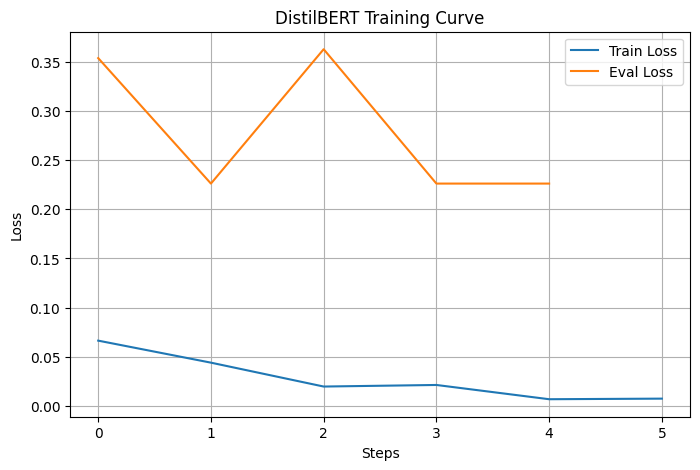

In [50]:
# ============================
# TASK: Save training curve plot
# ============================

import matplotlib.pyplot as plt

logs = trainer.state.log_history
train_loss = [entry["loss"] for entry in logs if "loss" in entry]
eval_loss  = [entry["eval_loss"] for entry in logs if "eval_loss" in entry]

plt.figure(figsize=(8,5))
plt.plot(train_loss, label="Train Loss")
plt.plot(eval_loss, label="Eval Loss")
plt.title("DistilBERT Training Curve")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.savefig("distilbert_training_curve.png", dpi=200, bbox_inches="tight")
print("Saved: distilbert_training_curve.png")
plt.show()


Saved: distilbert_confusion_matrix.png


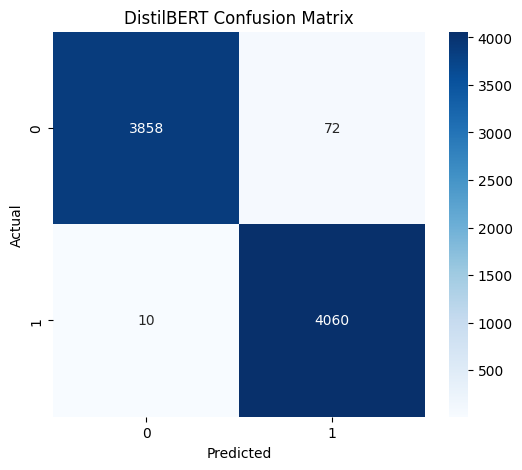

In [45]:
# ============================
# TASK: Create & Save Confusion Matrix
# ============================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("DistilBERT Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("distilbert_confusion_matrix.png", dpi=200, bbox_inches="tight")
print("Saved: distilbert_confusion_matrix.png")
plt.show()


In [46]:
# ============================
# TASK: Zip and download the DistilBERT model
# ============================

import shutil

shutil.make_archive("distilbert-saved", "zip", "./distilbert-saved")
print("Created: distilbert-saved.zip")


Created: distilbert-saved.zip


In [47]:
from google.colab import files
files.download("distilbert-saved.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [48]:
# ============================
# TASK: Download predictions CSV
# ============================

from google.colab import files
files.download("predictions_distilbert.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [51]:
# ============================
# TASK: Download PNG plots
# ============================

from google.colab import files
files.download("distilbert_confusion_matrix.png")
files.download("distilbert_training_curve.png")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>